In [1]:
# Import the required modules
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler

In [2]:
# Load the dataset
df = pd.read_csv('final_data.csv')

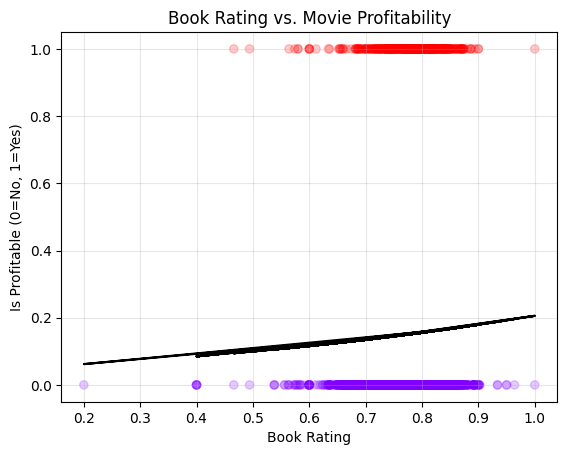

In [3]:
# Visualize the Data: Scatterplot of Logistic Regression
# Predict if movie is profitable based on book rating

x = df[['Book Rating']].dropna()
y = df['movie_profit'] > 0
y = y[x.index] # Align X and y after dropping NaN values

# Fit Logistic Regression model to draw a curve
model = LogisticRegression()
model.fit(x, y)

plt.scatter(x, y, c=y, cmap='rainbow', alpha = 0.2)

# curve reference: https://stackoverflow.com/questions/69446699/matplotlib-plot-curve-logistic-regression
plt.plot(x, model.predict_proba(x)[:,1], color="black") 

plt.grid(True, alpha=0.3)
plt.xlabel('Book Rating')
plt.ylabel('Is Profitable (0=No, 1=Yes)')
plt.title('Book Rating vs. Movie Profitability')
plt.show()

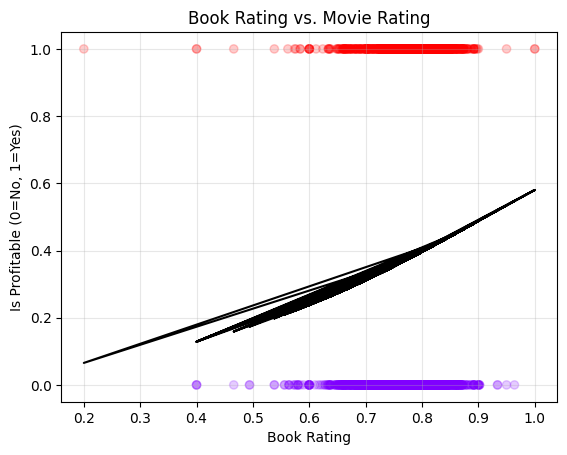

In [4]:
# Visualize the Data: Scatterplot of Logistic Regression
# Predict if movie is profitable based on book rating

x = df[['Book Rating']].dropna()
y = df['Movie Rating'] >= 0.7
y = y[x.index] # Align X and y after dropping NaN values

# Fit Logistic Regression model to draw a curve
model = LogisticRegression()
model.fit(x, y)

plt.scatter(x, y, c=y, cmap='rainbow', alpha = 0.2)

# curve reference: https://stackoverflow.com/questions/69446699/matplotlib-plot-curve-logistic-regression
plt.plot(x, model.predict_proba(x)[:,1], color="black") 

plt.grid(True, alpha=0.3)
plt.xlabel('Book Rating')
plt.ylabel('Is Profitable (0=No, 1=Yes)')
plt.title('Book Rating vs. Movie Rating')
plt.show()

In [5]:
df['Successful'] = ((df['Movie Rating'] >= 0.7) | (df['movie_profit'] > 0)).astype(int)

# Select features
feature_cols = ['Book Rating', 'Pages', 'RatingDistTotal', 'movie_budget', 'imdb_total_votes', 'movie_release']

# Create feature dataframe
x = df[feature_cols].copy()
y = df['Successful'].copy()

#mask = df['Book Rating'].notna() & df['Movie Rating'].notna()
#x = x[mask]
#y = y[mask]

x = x.fillna(x.median())

In [6]:
# Split the Dataset
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42, stratify=y)

In [7]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [8]:
# Test on number of observations
x_train.shape 

(2448, 6)

In [9]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(x_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [10]:
y_pred_train = log_reg.predict(x_train_scaled)
y_pred_test = log_reg.predict(x_test_scaled)
y_pred_proba_test = log_reg.predict_proba(x_test_scaled)[:, 1]

In [11]:
# Display the Confusion Matrix values
cm = confusion_matrix(y_test, y_pred_test, labels=[1,0])

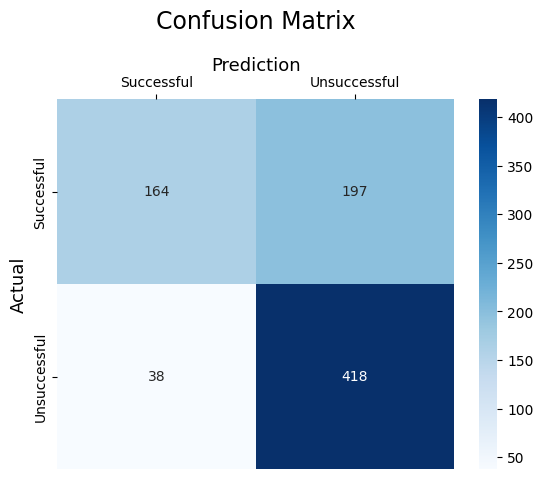

Classification Report:
              precision    recall  f1-score   support

Unsuccessful       0.68      0.92      0.78       456
  Successful       0.81      0.45      0.58       361

    accuracy                           0.71       817
   macro avg       0.75      0.69      0.68       817
weighted avg       0.74      0.71      0.69       817



In [12]:
# Confusion Matrix Heatmap
# Reference: https://www.geeksforgeeks.org/machine-learning/confusion-matrix-machine-learning/
sns.heatmap(cm, 
            annot=True,
            fmt='g', 
            cmap = "Blues",
            xticklabels=['Successful','Unsuccessful'],
            yticklabels=['Successful','Unsuccessful'])
plt.ylabel('Actual', fontsize=13)
plt.title('Confusion Matrix', fontsize=17, pad=20)
plt.gca().xaxis.set_label_position('top') 
plt.xlabel('Prediction', fontsize=13)
plt.gca().xaxis.tick_top()
plt.show()

# Classifications Report based on Confusion Metrics
print("Classification Report:")
print(classification_report(y_test, y_pred_test,
                          target_names=['Unsuccessful', 'Successful']))

/Users/mac/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


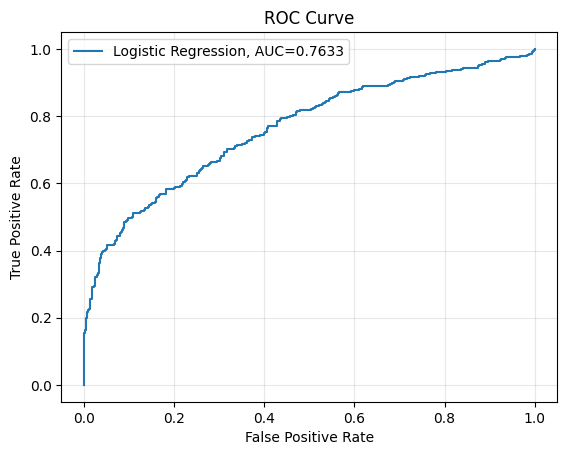

In [13]:
# Plot ROC Curve
# Reference: https://www.statology.org/plot-multiple-roc-curves-python/
from sklearn import metrics

#fit logistic regression model and plot ROC curve
model = LogisticRegression()
model.fit(x_train, y_train)
y_pred = model.predict_proba(x_test)[:, 1]
fpr, tpr, _ = metrics.roc_curve(y_test, y_pred)
auc = round(metrics.roc_auc_score(y_test, y_pred), 4)
plt.plot(fpr,tpr,label="Logistic Regression, AUC="+str(auc))
plt.grid(True, alpha=0.3)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

#add legend
plt.legend()

Logistic Regression Coefficients:
         Feature  Coefficient
imdb_total_votes     5.214077
   movie_release    -0.324927
     Book Rating     0.227726
    movie_budget    -0.077431
           Pages     0.063254
 RatingDistTotal     0.028490


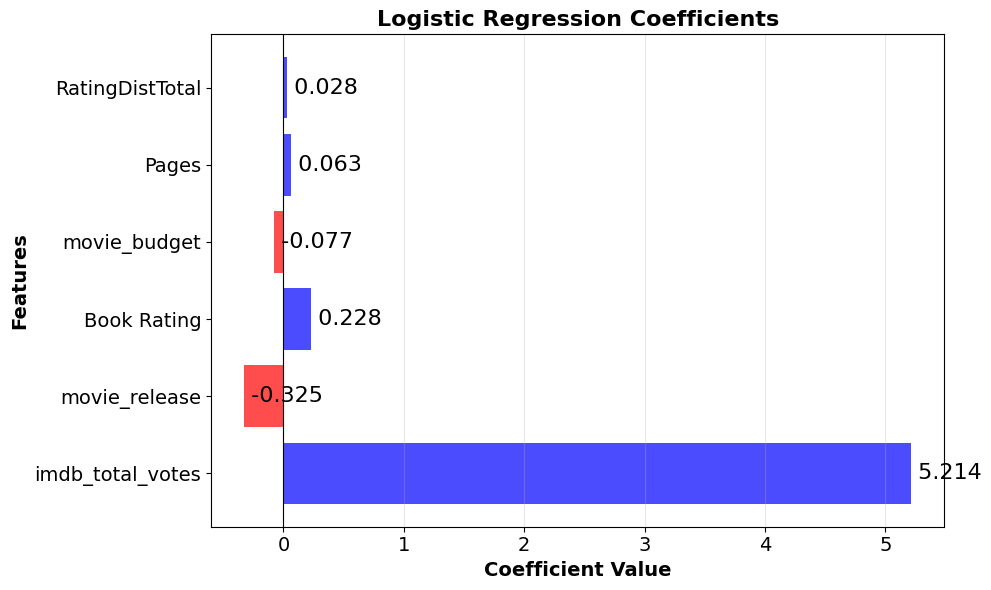

In [14]:
# Print Logistic Regression Coefficients
print("Logistic Regression Coefficients:")

# Get feature names and coefficients
feature_names = x_train.columns
coefficients = log_reg.coef_[0]

# Create a DataFrame for easy viewing
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', key=abs, ascending=False)

print(coef_df.to_string(index=False))

# Coefficient Plot
plt.figure(figsize=(10, 6))

# Create horizontal bar plot
colors = ['blue' if c > 0 else 'red' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.7)

# Add vertical line at x=0
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)

# Labels and title
plt.xlabel('Coefficient Value', fontsize=14, fontweight='bold')
plt.ylabel('Features', fontsize=14, fontweight='bold')
plt.title('Logistic Regression Coefficients', 
          fontsize=16, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

plt.yticks(fontsize=14)
plt.xticks(fontsize=14)

# Add value labels on bars
for i, (feature, coef) in enumerate(zip(coef_df['Feature'], coef_df['Coefficient'])):
    plt.text(coef, i, f' {coef:.3f}', va='center', fontsize=16)

plt.tight_layout()
plt.show()